In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline 

In [2]:
# Loading  
df = pd.read_csv(r"C:\Users\Utilisateur\Downloads\amz_uk_price_prediction_dataset.csv\amz_uk_price_prediction_dataset.csv")
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [24]:
# Generating a crosstab  
crosstab_result = pd.crosstab(df['category'], df['isBestSeller'])
ct['pct'] = crosstab_result[True] / (crosstab_result[True] +crosstab_result[False])
ct = ct.sort_values(by = 'pct', ascending = False)
ct.head(5)

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [26]:
from scipy.stats import chi2_contingency

# Chi-square test '
chi2_statistic, chi2_p_value, _, expected_freq = chi2_contingency(crosstab_result)

print(chi2_statistic, chi2_p_value)

36540.20270061387 0.0


In [27]:
from scipy.stats.contingency import association

# Computing the association between variables in 'crosstab_result' using the "cramer" method
association(crosstab_result, method="cramer")

0.1222829439760564

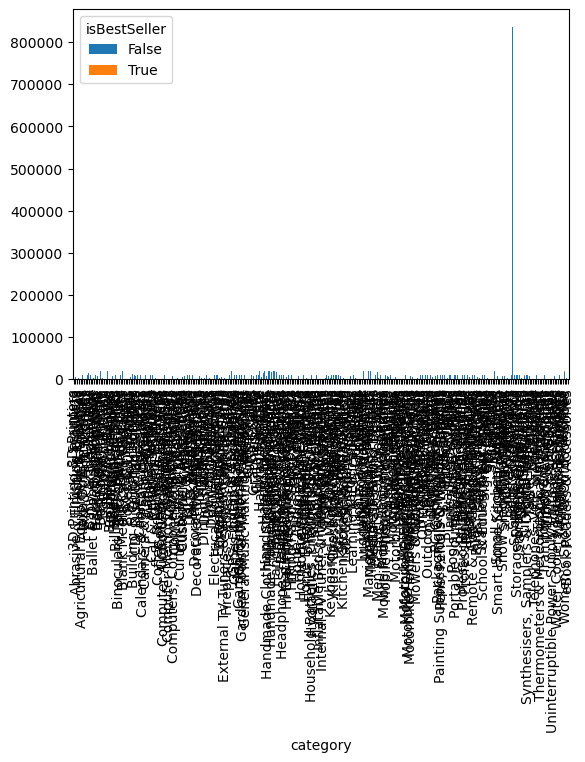

In [38]:
# Plotting a stacked bar chart for the 'crosstab_result' data
crosstab_result.plot(kind="bar", stacked=True);

### Part 1: Analyzing Best-Seller Trends Across Product Categories
**1. Top 3 categories where being a best-seller is more prevalent (> 50 %)**
- Grocery	 
- Smart Home Security & Lighting	 
- Health & Personal Care

**2. Statistical tests**

**Chi-square test to determine if the best-seller distribution is independent of the product category**
The null hypothesis of the Chi-square test is that the two categorical variables are independent. Given the  ( p )-value of 0 which is under 0.05, we reject the null hypothesis. This implies that there's a significant association between best-seller and product category in the dataset. However, the p-value is really close from the threshold of 0.05, which suggests a relative significance.

**Cramér's V**
The Cramér's V value of 0.12 suggests a weak association between the two variables. Though statistically significant, the strength of this relationship is not very strong in practical terms.

**3. Visualization**
crosstab_result.plot(kind="bar", stacked=True);

In [39]:

**0. Preliminary Step: Remove outliers in product prices**
def tukeys_test_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds for the outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify the outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]

    return outliers

In [52]:
# Identify outliers:
data_series = df['price']  # replace 'ColumnName' with your specific column
outliers = tukeys_test_outliers(data_series)
print(outliers)

10         139.00
19         164.99
25         149.99
28         289.00
31         199.99
            ...  
2443619    166.99
2443627    152.58
2443638    108.77
2443641    166.99
2443643    158.99
Name: price, Length: 327688, dtype: float64


In [68]:
outliers = pd.DataFrame(data=outliers)
outliers.reset_index()

,index,price
0,10,139.00
1,19,164.99
2,25,149.99
3,28,289.00
4,31,199.99
...,...,...
327683,2443619,166.99
327684,2443627,152.58
327685,2443638,108.77
327686,2443641,166.99


In [69]:
### Part 2: Exploring Product Prices and Ratings Across Categories and Brands
# **0. Preliminary Step: Remove outliers in product prices**
# outliers.to_frame()
df_filtered = df[~df['price'].isin(outliers['price'])]

In [76]:
### Part 2: Exploring Product Prices and Ratings Across Categories and Brands
# **1. Violin Plots**
top_categories = df_filtered['category'].value_counts().head(20).index #index permet de récupérer les noms des catégories seulement
df_filtered_category = df_filtered[df_filtered['category'].isin(top_categories)]

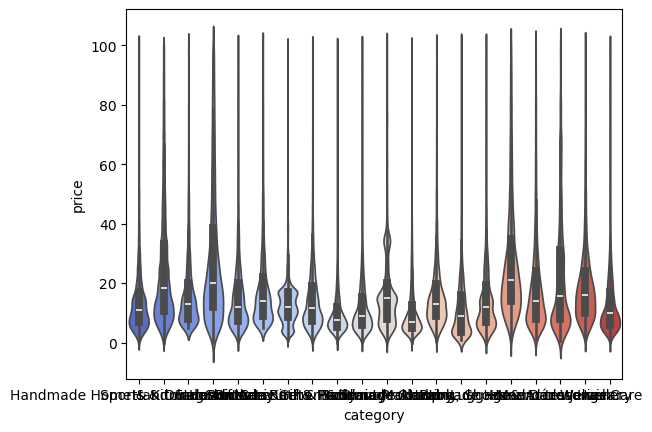

In [77]:
### Part 2: Exploring Product Prices and Ratings Across Categories and Brands
# **1. Violin Plots**
# Plotting a violin plot to visualize the distribution of 'price' for each 'category', using the "coolwarm" color palette
sns.violinplot(data=df_filtered_category, x='category', y='price', palette="coolwarm", hue='category', legend=False);

In [84]:
### Part 2: Exploring Product Prices and Ratings Across Categories and Brands
# **1. Violin Plots**
df_filtered_category.groupby(["category"]).median(['price']).sort_values(by = 'price', ascending = False).head(3)

,uid,stars,reviews,price,isBestSeller,boughtInLastMonth
category,,,,,,
Men,1848929.5,4.3,246.0,20.99,0.0,0.0
Fragrances,183034.0,4.3,17.0,20.00,0.0,0.0
Sports & Outdoors,1132147.5,0.0,0.0,18.32,0.0,0.0


**Men has the highest median price of $20.99**

<Axes: xlabel='category', ylabel='price'>

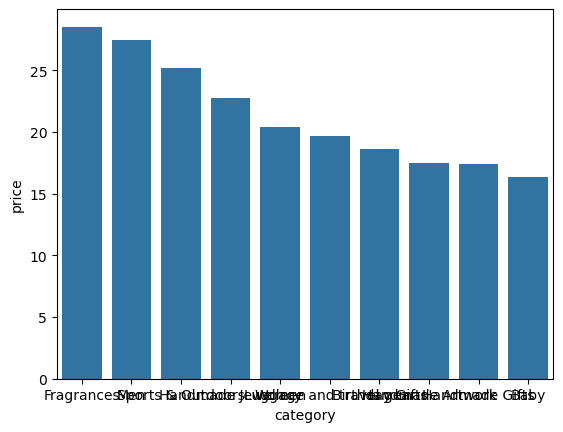

In [99]:
### Part 2: Exploring Product Prices and Ratings Across Categories and Brands
# **2. Bar Charts**
top10 = df_filtered_category.groupby(["category"]).mean(['price']).sort_values(by = 'price', ascending = False).head(10)
top10_bar = pd.DataFrame(data = top10).reset_index()
top10_bar = top10_bar[['category','price']]
sns.barplot(top10_bar, x="category", y="price")

**Fragrances has the highest average price of $28.54**

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Birthday Gifts'),
  Text(1, 0, 'Handmade Clothing, Shoes & Accessories'),
  Text(2, 0, 'Sports & Outdoors'),
  Text(3, 0, 'Handmade Gifts'),
  Text(4, 0, 'Make-up'),
  Text(5, 0, 'Manicure & Pedicure Products'),
  Text(6, 0, 'Bath & Body'),
  Text(7, 0, 'Beauty'),
  Text(8, 0, 'Hair Care'),
  Text(9, 0, 'Skin Care')])

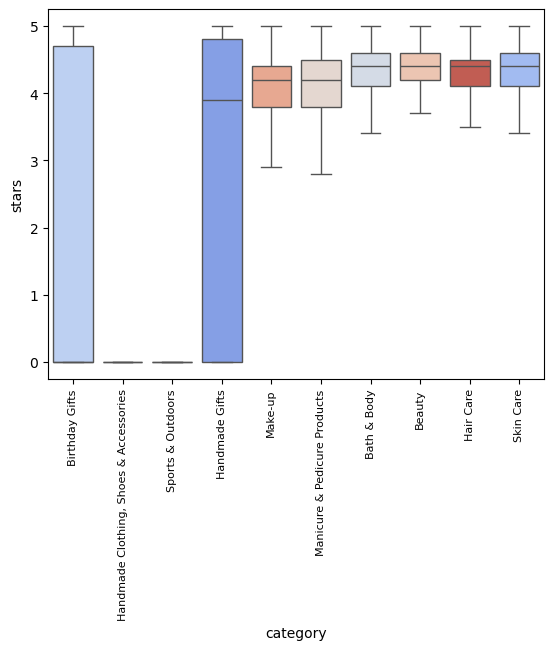

In [113]:
### Part 2: Exploring Product Prices and Ratings Across Categories and Brands
# **3. Box Plots**
top10_categories = df_filtered['category'].value_counts().head(10).index #index permet de récupérer les noms des catégories seulement
df_filtered_category_10 = df_filtered[df_filtered['category'].isin(top10_categories)]
df_filtered_category_10
#ordering to facilitate answers
order = df_filtered_category_10.groupby('category')['stars'].median().sort_values().index
# Plotting a box plot 
sns.boxplot(data=df_filtered_category_10, x='category', y='stars', palette="coolwarm", hue='category', legend=False, order = order, showfliers = False);
plt.xticks(rotation = 90, fontsize = 8)

**Skin Care has the highest median ratings over 4 stars**

In [116]:
### Part 3: Investigating the Interplay Between Product Prices and Ratings
# **1. Correlation Coefficients**
correlation = df['stars'].corr(df['price'], method='spearman')
correlation

np.float64(-0.1331642546243379)

**The Spearman correlation of (-0.133) indicates indicates a very weak (almost inexistent) and negative monotonic relationship between the two variables. This means that when one variable increases, the other also tends to decrease, and has almost no inlfuence on eahc other.**

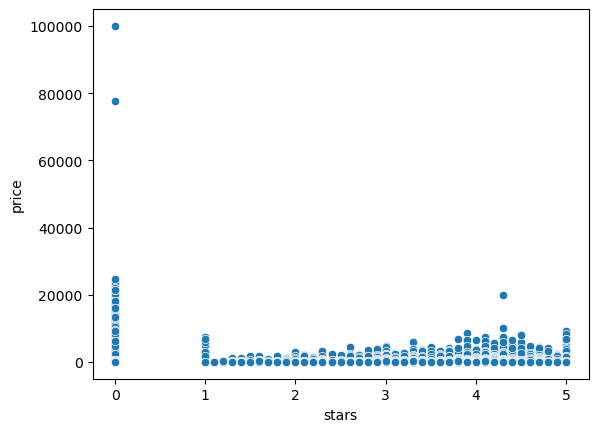

In [117]:
### Part 3: Investigating the Interplay Between Product Prices and Ratings
# **2. Visualisation**
# Plotting a scatter plot to visualize the relationship  
sns.scatterplot(data=df, x='stars', y='price');

**The scatterplot of ratings and prices indicates 1) many products with prices between 0 to near $28000 did get any rating 2) Most of the prodcuts rated are within a window of prices 3) Few outliers for both prices and ratings should be removed**

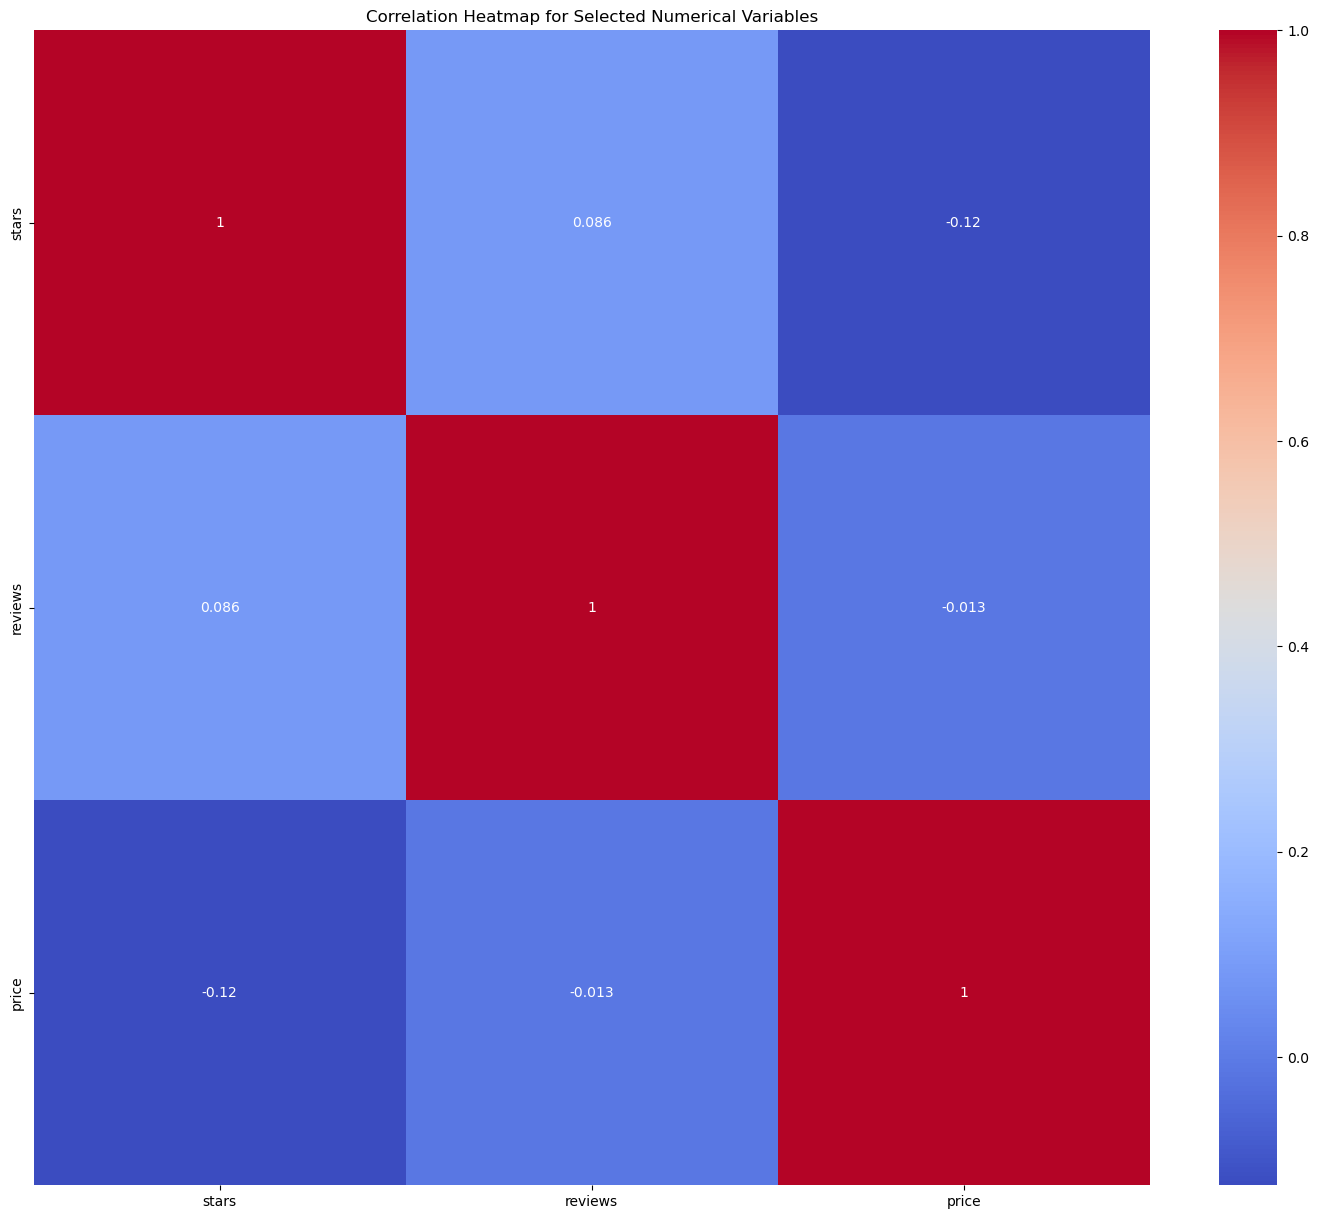

In [119]:
### Part 3: Investigating the Interplay Between Product Prices and Ratings
# **2. Visualisation**
# Plotting a correlation heatmap to visualize correlations between all numerical variables.
df_numerical =  df[['stars','reviews','price']]
correlation_matrix = df_numerical.corr()

# Setting up the matplotlib figure with an appropriate size
plt.figure(figsize=(18, 15))

# Drawing the heatmap for the numerical columns
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap for Selected Numerical Variables")
plt.show()

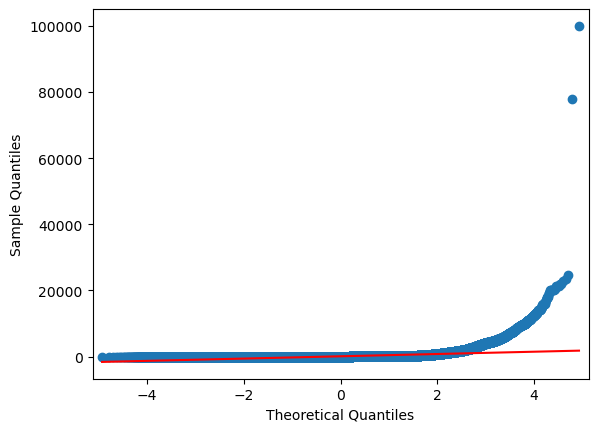

In [120]:
import statsmodels.api as sm
### Part 3: Investigating the Interplay Between Product Prices and Ratings
# **2. Visualisation**
# Generating a Q-Q plot to see if product prices typically follow a normal distribution  
sm.qqplot(df['price'], line='s');

from the QQ plot of price:

Lower Tail: In the lower tail (left side of the plot), the data points follow the red line. This indicates a normal distribution.
Upper Tail: In the upper tail (right side of the plot), the data points deviate significantly from the red line, suggesting a long tail or skewness to the right. This indicates that there are more extreme high values than would be expected in a normal distribution.
Central Portion: The central portion of the data points align perfectly with the line, suggesting a normal distribution as well.
Conclusion:
The price data is not normally distributed. It appears to be right-skewed with potential outliers on the higher end and has right heavier tail than a normal distribution. This could influence decisions about data transformations or the types of statistical methods applied to the data. For instance, a log transformation could be considered to address the skewness and make the data more normally distributed.